<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/04_1_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning with Iris Dataset

* This code introduces unsupervised deep learning for clustering using an autoencoder with Python, Keras, and TensorFlow.
* We'll load and preprocess the Iris dataset, design and train a simple autoencoder to learn a compressed data representation, and then apply K-Means clustering to these learned features.
* The process culminates in visualizing and evaluating the clusters to understand how deep learning can effectively group data without explicit labels.

--- Step 1 & 2: Loading and Preprocessing Data ---
Original data shape: (150, 4)
True labels (first 10): [0 0 0 0 0 0 0 0 0 0]
Scaled data shape: (150, 4)
Sample of scaled data (first 2 rows):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]]
--------------------------------------------------
--- Step 3: Designing the Autoencoder Model ---


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_hidden (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_hidden (Dense)          │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118 (472.00 B)

 Trainable params: 118 (472.00 B)

 Non-trainable params: 0 (0.00 B)

--------------------------------------------------
--- Step 4: Training the Autoencoder ---
Training finished.


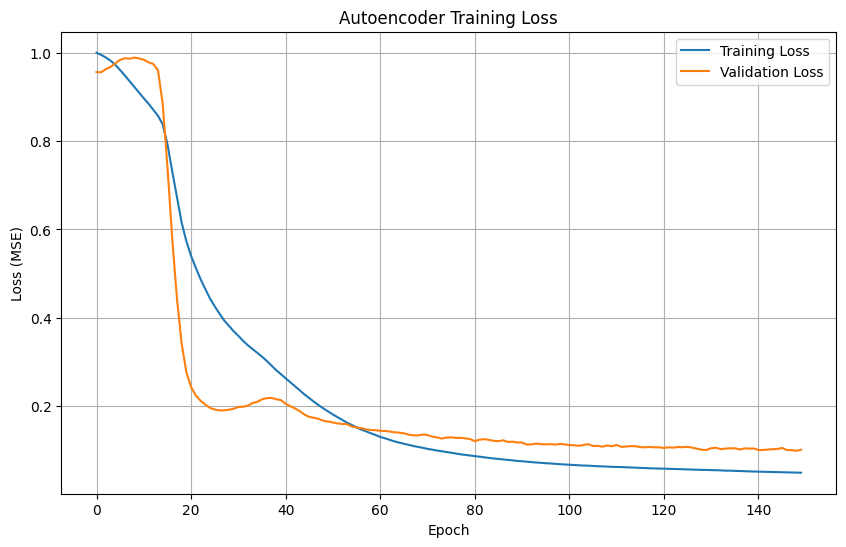

--------------------------------------------------
--- Step 5: Extracting Latent Space Representation ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Latent space representation shape: (150, 2)
Sample of latent space data (first 2 rows):
[[0.42650935 1.6858203 ]
 [1.048162   2.5054908 ]]
--------------------------------------------------
--- Step 6: Performing K-Means Clustering on Latent Space ---
Cluster assignments (first 10 samples): [1 1 1 1 1 1 1 1 2 1]
--------------------------------------------------
--- Step 7: Visualizing Clusters ---


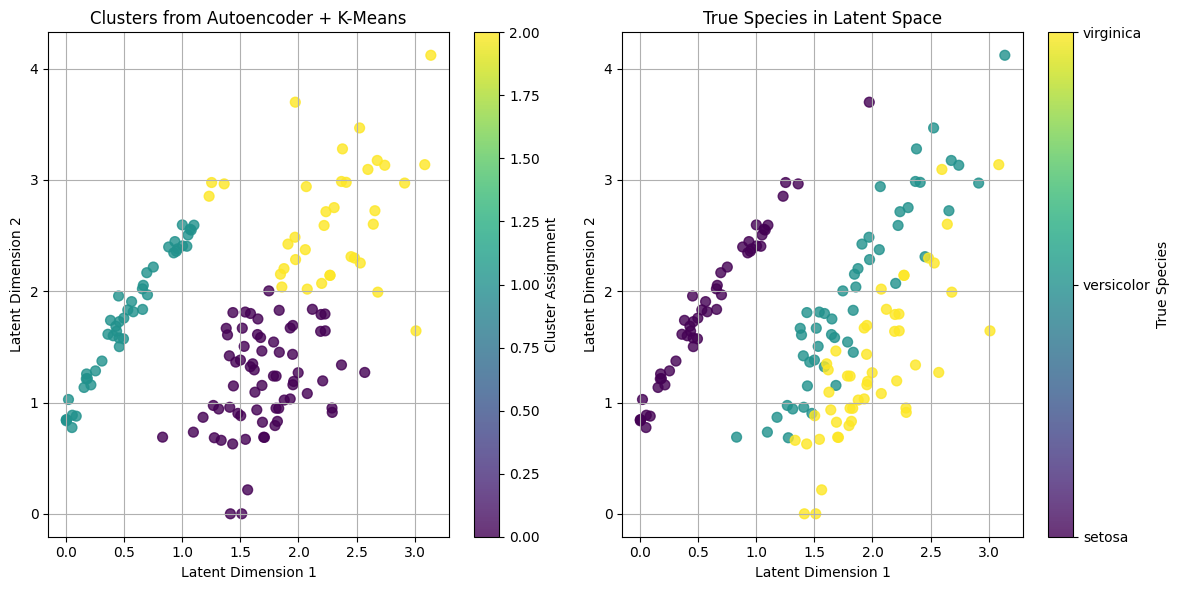

--------------------------------------------------
--- Step 8: Evaluating Clustering Performance ---
Adjusted Rand Index (ARI) for Autoencoder + K-Means: 0.469
Silhouette Score for Autoencoder + K-Means: 0.471

--- K-Means directly on scaled data ---
Adjusted Rand Index (ARI) direct: 0.620
Silhouette Score direct: 0.460
--------------------------------------------------


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Not used in final model but useful for general visualization
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.metrics import adjusted_rand_score, silhouette_score

print("--- Step 1 & 2: Loading and Preprocessing Data ---")
iris = load_iris()
X = iris.data # Features
y_true = iris.target # True labels (for evaluation later)
feature_names = iris.feature_names

print(f"Original data shape: {X.shape}")
print(f"True labels (first 10): {y_true[:10]}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Sample of scaled data (first 2 rows):\n{X_scaled[:2, :]}")
print("-" * 50)

print("--- Step 3: Designing the Autoencoder Model ---")
input_dim = X_scaled.shape[1] # Number of features (4 for Iris)
encoding_dim = 2 # Dimension of the latent space (for visualization)

# Encoder
input_layer = keras.Input(shape=(input_dim,), name='input_layer')
encoder_hidden = layers.Dense(8, activation='relu', name='encoder_hidden')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu', name='latent_space')(encoder_hidden)

# Decoder
decoder_hidden = layers.Dense(8, activation='relu', name='decoder_hidden')(encoded)
decoded = layers.Dense(input_dim, activation='linear', name='output_layer')(decoder_hidden)

# Autoencoder model
autoencoder = keras.Model(inputs=input_layer, outputs=decoded, name='autoencoder')

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Display model summary
autoencoder.summary()
print("-" * 50)

print("--- Step 4: Training the Autoencoder ---")
history = autoencoder.fit(X_scaled, X_scaled,
                          epochs=150, # Increased epochs for better learning
                          batch_size=16,
                          shuffle=True,
                          validation_split=0.1,
                          verbose=0) # Set to 1 to see epoch-by-epoch progress

print("Training finished.")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()
print("-" * 50)

print("--- Step 5: Extracting Latent Space Representation ---")
encoder_model = keras.Model(inputs=input_layer, outputs=encoded, name='encoder_model')
X_latent = encoder_model.predict(X_scaled)

print(f"Latent space representation shape: {X_latent.shape}")
print(f"Sample of latent space data (first 2 rows):\n{X_latent[:2, :]}")
print("-" * 50)

print("--- Step 6: Performing K-Means Clustering on Latent Space ---")
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_latent)

print(f"Cluster assignments (first 10 samples): {clusters[:10]}")
print("-" * 50)

print("--- Step 7: Visualizing Clusters ---")

# Plot clusters identified by K-Means on latent space
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_latent[:, 0], X_latent[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.8)
plt.title('Clusters from Autoencoder + K-Means')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.colorbar(scatter, label='Cluster Assignment')
plt.grid(True)

# Plot true species labels on latent space for comparison
plt.subplot(1, 2, 2)
scatter_true = plt.scatter(X_latent[:, 0], X_latent[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('True Species in Latent Space')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
# Custom colorbar for true species names
cbar = plt.colorbar(scatter_true, ticks=[0, 1, 2], format=plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)]), label='True Species')
plt.grid(True)

plt.tight_layout()
plt.show()
print("-" * 50)

print("--- Step 8: Evaluating Clustering Performance ---")

ari = adjusted_rand_score(y_true, clusters)
silhouette = silhouette_score(X_latent, clusters)

print(f"Adjusted Rand Index (ARI) for Autoencoder + K-Means: {ari:.3f}")
print(f"Silhouette Score for Autoencoder + K-Means: {silhouette:.3f}")

# Compare with direct K-Means on original scaled data
kmeans_direct = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters_direct = kmeans_direct.fit_predict(X_scaled)
ari_direct = adjusted_rand_score(y_true, clusters_direct)
silhouette_direct = silhouette_score(X_scaled, clusters_direct)

print(f"\n--- K-Means directly on scaled data ---")
print(f"Adjusted Rand Index (ARI) direct: {ari_direct:.3f}")
print(f"Silhouette Score direct: {silhouette_direct:.3f}")
print("-" * 50)